In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, log_loss, average_precision_score
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
import shap
import joblib
from sklearn.inspection import PartialDependenceDisplay
from sklearn.isotonic import IsotonicRegression

try:
    import seaborn as sns
except:
    ! pip install seaborn
    import seaborn as sns
    
try:
    import optuna
except:
    ! pip install optuna
    import optuna
    
try:
    from xgboost import XGBClassifier
except:
    !pip install 'xgboost>=2.0,<3.0'
    from xgboost import XGBClassifier

optuna.logging.set_verbosity(optuna.logging.WARNING)

/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


## Helper Classes and Functions

In [2]:
class GenericCleaning:
    def __init__(self):
        pass
    def fit(self, X):
        print('Generic cleaning...')
        return self
    def transform(self, X):
        print('Generic cleaning...')
        X = X.copy()
        # replace terms w val 0
        X['term_months'] = X['term_months'].replace(0, np.nan)
        # clean channel
        X['channel'] = X['channel'].str.lower().str.strip()
        return X

In [3]:
class FillMissing:
    def __init__(self, dict_fillna):
        self.dict_fillna = dict_fillna
    def fit(self, X):
        print('Calculating imputation value...')
        dict_impute = {}
        for key, val in tqdm(self.dict_fillna.items()):
            if val == 'max':
                val_impute = X[key].max()
            elif val == 'min':
                val_impute = X[key].min()
            elif val == 'missing':
                val_impute = 'missing'
            # assign
            dict_impute[key] = val_impute
        # save to object
        self.dict_impute = dict_impute
        return self
    def transform(self, X):
        print('Filling missing values...')
        X = X.copy()
        dict_impute = self.dict_impute
        list_cols = list(X.columns)
        dict_impute = {key: val for key, val in dict_impute.items() if key in list_cols}
        # impute
        for key, val in tqdm(dict_impute.items()):
            X[key] = X[key].fillna(val)
        return X

In [4]:
class FeatureEngineering:
    def __init__(self):
        pass
    def fit(self, X):
        print('Feature engineering...')
        # get unique channels
        list_channels_unique = list(X['channel'].unique())
        # save to object
        self.list_channels_unique = list_channels_unique
        return self
    def transform(self, X):
        print('Feature engineering...')
        X = X.copy()
        # log income
        X['ENG-stated_income_log'] = np.log1p(X['stated_income'])
        # loan to income
        X['ENG-loan_to_income'] = X['loan_amount'] / (X['stated_income'] + 1)
        # one-hot encode channel
        for channel_unique in self.list_channels_unique:
            X[f'ENG-channel_{channel_unique}'] = (X['channel'] == channel_unique).astype(int)
        return X

In [5]:
class Winsorize:
    def __init__(self, list_cols_winsorize):
        self.list_cols_winsorize = list_cols_winsorize
    def fit(self, X):
        print('Calculating winsorization thresholds...')
        dict_bounds = {}
        for col in self.list_cols_winsorize:
            flt_lower = X[col].quantile(0.01)
            flt_upper = X[col].quantile(0.99)
            dict_bounds[col] = {'lower': flt_lower, 'upper': flt_upper}
        # save
        self.dict_bounds = dict_bounds
        return self
    def transform(self, X):
        print('Winsorizing features...')
        X = X.copy()
        dict_bounds = self.dict_bounds
        list_cols = list(X.columns)
        dict_bounds = {key: val for key, val in dict_bounds.items() if key in list_cols}
        for key, val in dict_bounds.items():
            X[key] = X[key].clip(val['lower'], val['upper'])
        return X

In [6]:
class PreprocessingModel:
    def __init__(self, list_cls_transformers):
        self.list_cls_transformers = list_cls_transformers
    def transform(self, X):
        for cls_transformer in self.list_cls_transformers:
            X = cls_transformer.transform(X)
        return X

In [7]:
def tune_model_optuna(X_train, y_train, X_valid, y_valid, X_test, y_test,
                      dict_monotone_constraints, n_trials=10):
    """Bayesian hyperparameter optimization using Optuna."""
    flt_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    
    # filter monotone constraints to current features
    dict_mc = {k: v for k, v in dict_monotone_constraints.items() if k in X_train.columns}
    
    best_model = [None]
    
    def objective(trial):
        # let optuna decide whether to use class weighting
        use_class_weight = trial.suggest_categorical('use_class_weight', [True, False])
        spw = flt_pos_weight if use_class_weight else 1.0
        
        params = {
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
            'max_depth': trial.suggest_int('max_depth', 2, 6),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
            'gamma': trial.suggest_float('gamma', 0.0, 1.0),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 10.0, log=True),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        }
        
        model = XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            n_estimators=2000,
            scale_pos_weight=spw,
            monotone_constraints=dict_mc,
            random_state=42,
            early_stopping_rounds=50,
            tree_method="hist",
            **params,
        )
        model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)
        
        y_hat_valid = model.predict_proba(X_valid)[:, 1]
        score = average_precision_score(y_valid, y_hat_valid)
        
        # track best model
        if best_model[0] is None or score > best_model[0][1]:
            best_model[0] = (model, score)
        
        return score
    
    # run optimization with progress bar
    pbar = tqdm(total=n_trials, desc=f'Optuna ({X_train.shape[1]} features)')
    def callback(study, trial):
        pbar.update(1)
        pbar.set_postfix({'best_pr_auc': f'{study.best_value:.4f}'})
    
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, callbacks=[callback])
    pbar.close()
    
    # get the best model and evaluate on all sets
    cls_model = best_model[0][0]
    y_hat_train = cls_model.predict_proba(X_train)[:, 1]
    y_hat_valid = cls_model.predict_proba(X_valid)[:, 1]
    y_hat_test = cls_model.predict_proba(X_test)[:, 1]
    
    dict_result = {
        'int_n_features': X_train.shape[1],
        'list_features': list(X_train.columns),
        'flt_roc_auc_train': roc_auc_score(y_train, y_hat_train),
        'flt_roc_auc_valid': roc_auc_score(y_valid, y_hat_valid),
        'flt_roc_auc_test': roc_auc_score(y_test, y_hat_test),
        'flt_pr_auc_train': average_precision_score(y_train, y_hat_train),
        'flt_pr_auc_valid': average_precision_score(y_valid, y_hat_valid),
        'flt_pr_auc_test': average_precision_score(y_test, y_hat_test),
        'best_params': study.best_params,
        'cls_model_inference': cls_model,
    }
    return dict_result

## Constants

In [8]:
str_bucket = 'credit-risk-model-demo'
print(f'Bucket: {str_bucket}')

str_task = '03_xgboost'
print(f'Task: {str_task}')

str_dirname_output = './output'

str_target = 'default_12m'

# data uri - import
str_filename = 'df.csv'
str_uri = f's3://{str_bucket}/02_split_data/{str_filename}'

# id cols
list_cols_no = [
    'loan_id',
    'origination_date',
    'dob', # dont want to FE age for compliance reasons
    #str_target,
    'charged_off_amount',
    'paid_interest_amount',
    'apr', # dont have until loan is scored
    'state', # can be sparse in states and cause overfitting + very hard to defend
    # 'data_set',
]

Bucket: credit-risk-model-demo
Task: 03_xgboost


## Output Directory

In [9]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

## Import Data

In [10]:
df = pd.read_csv(str_uri)

/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/fsspec/registry.py:301: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)


## Drop Post-Origination and Non-Predictive Columns

In [11]:
df.drop(list_cols_no, axis=1, inplace=True)
df

,loan_amount,term_months,channel,employment_length_years,stated_income,has_prior_loans_with_us,bureau_score,open_trades,delinq_12m,utilization,inquiries_6m,public_records,default_12m,data_set
0,5410,18,partner,8.39,2951.0,0,604.0,1.0,1.0,0.47,3.0,1,0,train
1,10000,12,web,4.52,5410.0,0,600.0,2.0,0.0,0.46,3.0,0,0,train
2,8480,12,web,3.81,3244.0,0,557.0,2.0,0.0,0.48,5.0,2,0,train
3,3510,18,web,9.82,5147.0,1,651.0,3.0,0.0,0.18,1.0,0,0,train
4,6630,24,web,4.99,6389.0,1,611.0,1.0,0.0,0.41,3.0,1,0,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25303,6970,12,mobile,9.41,6511.0,0,607.0,2.0,1.0,0.47,4.0,1,0,test
25304,8450,12,mobile,8.97,4278.0,1,662.0,6.0,0.0,0.52,2.0,0,0,test
25305,970,24,web,4.01,3885.0,0,595.0,2.0,0.0,0.34,0.0,0,0,test
25306,5700,12,mobile,7.10,13121.0,0,583.0,2.0,0.0,0.31,2.0,2,0,test


## Extract Training Data (Fit Preprocessing on Training Only)

In [12]:
df_train = df[df['data_set'] == 'train'].copy()
df_train.drop('data_set', axis=1, inplace=True)
# X, y
list_cols = [col for col in df_train.columns if col != str_target]
X_train = df_train[list_cols].copy()
y_train = df_train[str_target]

## Build Preprocessing Pipeline (Fit on Training Data)

### Generic Cleaning

In [13]:
cls_cleaning = GenericCleaning()
cls_cleaning.fit(X_train)
X_train = cls_cleaning.transform(X_train)

Generic cleaning...
Generic cleaning...


### Pessimistic Imputation

In [14]:
dict_fillna = {
    'loan_amount': 'max',
    'term_months': 'min',
    'channel': 'missing',
    'employment_length_years': 'min',
    'stated_income': 'min',
    'has_prior_loans_with_us': 'min',
    'bureau_score': 'min',
    'open_trades': 'min',
    'delinq_12m': 'max',
    'utilization': 'max',
    'inquiries_6m': 'max',
    'public_records': 'max',
}
cls_impute = FillMissing(dict_fillna)
# fit
cls_impute.fit(X_train)
# transform
X_train = cls_impute.transform(X_train)

Calculating imputation value...


100%|██████████| 12/12 [00:00<00:00, 3435.61it/s]


Filling missing values...


100%|██████████| 12/12 [00:00<00:00, 2111.67it/s]


### Feature Engineering

In [15]:
cls_fe = FeatureEngineering()
# fit
cls_fe.fit(X_train)
# transform
X_train = cls_fe.transform(X_train)

Feature engineering...
Feature engineering...


### Winsorization (Not Included in Final Pipeline for XGBoost)

In [16]:
list_cols_winsorize = [
    'employment_length_years',
    'bureau_score',
    'open_trades',
    'delinq_12m',
    'utilization',
    'inquiries_6m',
    'ENG-stated_income_log',
    'ENG-loan_to_income',
]
cls_winsorize = Winsorize(list_cols_winsorize=list_cols_winsorize)
# fit
cls_winsorize.fit(X_train)
# transform
X_train = cls_winsorize.transform(X_train)

Calculating winsorization thresholds...
Winsorizing features...


### Assemble Preprocessing Pipeline

In [17]:
# list of transformers
list_cls_transformers = [
    cls_cleaning,
    cls_impute,
    cls_fe,
    #cls_winsorize,
]
cls_model_preprocessing = PreprocessingModel(
    list_cls_transformers=list_cls_transformers,
)

### Save Preprocessing Pipeline

In [18]:
# save
str_filename = 'cls_model_preprocessing.joblib'
str_local_path = f'{str_dirname_output}/{str_filename}'
joblib.dump(cls_model_preprocessing, str_local_path)

['./output/cls_model_preprocessing.joblib']

### Load Pipeline (Simulate Production)

In [19]:
cls_model_preprocessing = joblib.load(str_local_path)

## Transform Full Dataset (Pipeline Was Fit on Training Only)

In [20]:
df = cls_model_preprocessing.transform(
    X=df,
)
# show
df

Generic cleaning...
Filling missing values...


100%|██████████| 12/12 [00:00<00:00, 1005.45it/s]

Feature engineering...


,loan_amount,term_months,channel,employment_length_years,stated_income,has_prior_loans_with_us,bureau_score,open_trades,delinq_12m,utilization,inquiries_6m,public_records,default_12m,data_set,ENG-stated_income_log,ENG-loan_to_income,ENG-channel_partner,ENG-channel_web,ENG-channel_missing,ENG-channel_mobile
0,5410,18.0,partner,8.39,2951.0,0,604.0,1.0,1.0,0.47,3.0,1,0,train,7.990238,1.832656,1,0,0,0
1,10000,12.0,web,4.52,5410.0,0,600.0,2.0,0.0,0.46,3.0,0,0,train,8.596189,1.848087,0,1,0,0
2,8480,12.0,web,3.81,3244.0,0,557.0,2.0,0.0,0.48,5.0,2,0,train,8.084871,2.613251,0,1,0,0
3,3510,18.0,web,9.82,5147.0,1,651.0,3.0,0.0,0.18,1.0,0,0,train,8.546364,0.681818,0,1,0,0
4,6630,24.0,web,4.99,6389.0,1,611.0,1.0,0.0,0.41,3.0,1,0,train,8.762490,1.037559,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25303,6970,12.0,mobile,9.41,6511.0,0,607.0,2.0,1.0,0.47,4.0,1,0,test,8.781402,1.070332,0,0,0,1
25304,8450,12.0,mobile,8.97,4278.0,1,662.0,6.0,0.0,0.52,2.0,0,0,test,8.361475,1.974760,0,0,0,1
25305,970,24.0,web,4.01,3885.0,0,595.0,2.0,0.0,0.34,0.0,0,0,test,8.265136,0.249614,0,1,0,0
25306,5700,12.0,mobile,7.10,13121.0,0,583.0,2.0,0.0,0.31,2.0,2,0,test,9.482045,0.434385,0,0,0,1


## Feature Selection

In [21]:
list_cols_start = [
    #'loan_amount', # dont use because we have loan to income
    'term_months',
    'employment_length_years',
    'has_prior_loans_with_us',
    'bureau_score',
    'open_trades',
    'delinq_12m',
    'utilization',
    'inquiries_6m',
    'public_records',
    'ENG-stated_income_log',
    'ENG-loan_to_income',
    'ENG-channel_missing',
    'ENG-channel_mobile',
    'ENG-channel_partner',
    'ENG-channel_web',
    str_target,
    'data_set',
]
df = df[list_cols_start].copy()
df

,term_months,employment_length_years,has_prior_loans_with_us,bureau_score,open_trades,delinq_12m,utilization,inquiries_6m,public_records,ENG-stated_income_log,ENG-loan_to_income,ENG-channel_missing,ENG-channel_mobile,ENG-channel_partner,ENG-channel_web,default_12m,data_set
0,18.0,8.39,0,604.0,1.0,1.0,0.47,3.0,1,7.990238,1.832656,0,0,1,0,0,train
1,12.0,4.52,0,600.0,2.0,0.0,0.46,3.0,0,8.596189,1.848087,0,0,0,1,0,train
2,12.0,3.81,0,557.0,2.0,0.0,0.48,5.0,2,8.084871,2.613251,0,0,0,1,0,train
3,18.0,9.82,1,651.0,3.0,0.0,0.18,1.0,0,8.546364,0.681818,0,0,0,1,0,train
4,24.0,4.99,1,611.0,1.0,0.0,0.41,3.0,1,8.762490,1.037559,0,0,0,1,0,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25303,12.0,9.41,0,607.0,2.0,1.0,0.47,4.0,1,8.781402,1.070332,0,1,0,0,0,test
25304,12.0,8.97,1,662.0,6.0,0.0,0.52,2.0,0,8.361475,1.974760,0,1,0,0,0,test
25305,24.0,4.01,0,595.0,2.0,0.0,0.34,0.0,0,8.265136,0.249614,0,0,0,1,0,test
25306,12.0,7.10,0,583.0,2.0,0.0,0.31,2.0,2,9.482045,0.434385,0,1,0,0,0,test


## Train / Validation / Test Split

In [22]:
df_train = df[df['data_set'] == 'train'].copy()
df_valid = df[df['data_set'] == 'valid'].copy()
df_test = df[df['data_set'] == 'test'].copy()

## X, y Split

In [23]:
list_cols = [col for col in list_cols_start if col not in [str_target, 'data_set']]

# train
X_train = df_train[list_cols].copy()
y_train = df_train[str_target]

# valid
X_valid = df_valid[list_cols].copy()
y_valid = df_valid[str_target]

# test
X_test = df_test[list_cols].copy()
y_test = df_test[str_target]

## Monotone Constraints (Enforce Credit Intuition)

In [24]:
dict_monotone_constraints = {
    'term_months': -1,
    'employment_length_years': -1,
    'has_prior_loans_with_us': -1,
    'bureau_score': -1,
    'open_trades': -1,
    'delinq_12m': 1,
    'utilization': 1,
    'inquiries_6m': 1,
    'public_records': 1,
    'ENG-stated_income_log': -1,
    'ENG-loan_to_income': 1,
}

## Bayesian Optimization with Dynamic Feature Elimination

For each iteration:
1. Tune hyperparameters with Optuna (Bayesian optimization)
2. Evaluate the best model
3. Identify the feature with the lowest gain importance
4. Remove it and repeat

In [25]:
list_cols_model = list(list_cols)  # start with all features
list_results = []
int_min_features = 2
int_patience = 2  # stop if no improvement for this many rounds
flt_best_valid = -np.inf
int_no_improve = 0

while len(list_cols_model) >= int_min_features:
    print(f'\n{"="*60}')
    print(f'Tuning with {len(list_cols_model)} features')
    print(f'{"="*60}')
    
    dict_result = tune_model_optuna(
        X_train=X_train[list_cols_model],
        y_train=y_train,
        X_valid=X_valid[list_cols_model],
        y_valid=y_valid,
        X_test=X_test[list_cols_model],
        y_test=y_test,
        dict_monotone_constraints=dict_monotone_constraints,
        n_trials=10,
    )
    list_results.append(dict_result)
    
    flt_valid = dict_result['flt_pr_auc_valid']
    print(f'\nPR AUC - Train: {dict_result["flt_pr_auc_train"]:.4f} | '
          f'Valid: {flt_valid:.4f} | '
          f'Test: {dict_result["flt_pr_auc_test"]:.4f}')
    
    # early stopping check
    if flt_valid > flt_best_valid:
        flt_best_valid = flt_valid
        int_no_improve = 0
    else:
        int_no_improve += 1
        print(f'No improvement for {int_no_improve}/{int_patience} rounds')
        if int_no_improve >= int_patience:
            print('Early stopping triggered.')
            break
    
    # get feature importance by gain
    cls_model = dict_result['cls_model_inference']
    booster = cls_model.get_booster()
    dict_gain = booster.get_score(importance_type='gain')
    list_zero_gain = [f for f in list_cols_model if f not in dict_gain]
    
    if list_zero_gain:
        str_remove = list_zero_gain[0]
        print(f'Removing (zero gain): {str_remove}')
    elif len(list_cols_model) > int_min_features:
        str_remove = min(dict_gain, key=dict_gain.get)
        print(f'Removing (lowest gain={dict_gain[str_remove]:.4f}): {str_remove}')
    else:
        break
    
    list_cols_model = [c for c in list_cols_model if c != str_remove]

# create results dataframe
df_tuning = pd.DataFrame(list_results)
df_tuning.sort_values(by='flt_pr_auc_valid', ascending=False, inplace=True)
df_tuning[['int_n_features', 'flt_roc_auc_train', 'flt_roc_auc_valid', 'flt_roc_auc_test',
           'flt_pr_auc_train', 'flt_pr_auc_valid', 'flt_pr_auc_test']]


Tuning with 15 features


Optuna (15 features): 100%|██████████| 10/10 [00:15<00:00,  1.58s/it, best_pr_auc=0.4922]



PR AUC - Train: 0.5439 | Valid: 0.4922 | Test: 0.4978
Removing (zero gain): ENG-channel_missing

Tuning with 14 features


Optuna (14 features): 100%|██████████| 10/10 [00:16<00:00,  1.68s/it, best_pr_auc=0.4952]



PR AUC - Train: 0.5565 | Valid: 0.4952 | Test: 0.4973
Removing (lowest gain=1.5248): ENG-channel_partner

Tuning with 13 features


...

Optuna (9 features): 100%|██████████| 10/10 [00:21<00:00,  2.15s/it, best_pr_auc=0.4922]



PR AUC - Train: 0.5565 | Valid: 0.4922 | Test: 0.4976
No improvement for 1/2 rounds
Removing (lowest gain=2.8763): open_trades

Tuning with 8 features


Optuna (8 features): 100%|██████████| 10/10 [00:12<00:00,  1.23s/it, best_pr_auc=0.4888]



PR AUC - Train: 0.5517 | Valid: 0.4888 | Test: 0.4974
No improvement for 2/2 rounds
Early stopping triggered.


,int_n_features,flt_roc_auc_train,flt_roc_auc_valid,flt_roc_auc_test,flt_pr_auc_train,flt_pr_auc_valid,flt_pr_auc_test
5,10,0.828040,0.800319,0.800812,0.554734,0.495381,0.495786
3,12,0.828387,0.800095,0.800035,0.553822,0.495375,0.496276
1,14,0.829952,0.800235,0.800521,0.556535,0.495243,0.497288
2,13,0.829205,0.800511,0.800493,0.553073,0.493837,0.498637
4,11,0.831381,0.800184,0.800548,0.555231,0.492831,0.497443
6,9,0.829710,0.799568,0.799871,0.556476,0.492248,0.497581
0,15,0.825064,0.800226,0.800502,0.543946,0.492160,0.497783
7,8,0.827354,0.799569,0.800851,0.551672,0.488790,0.497363


## Feature Elimination Path

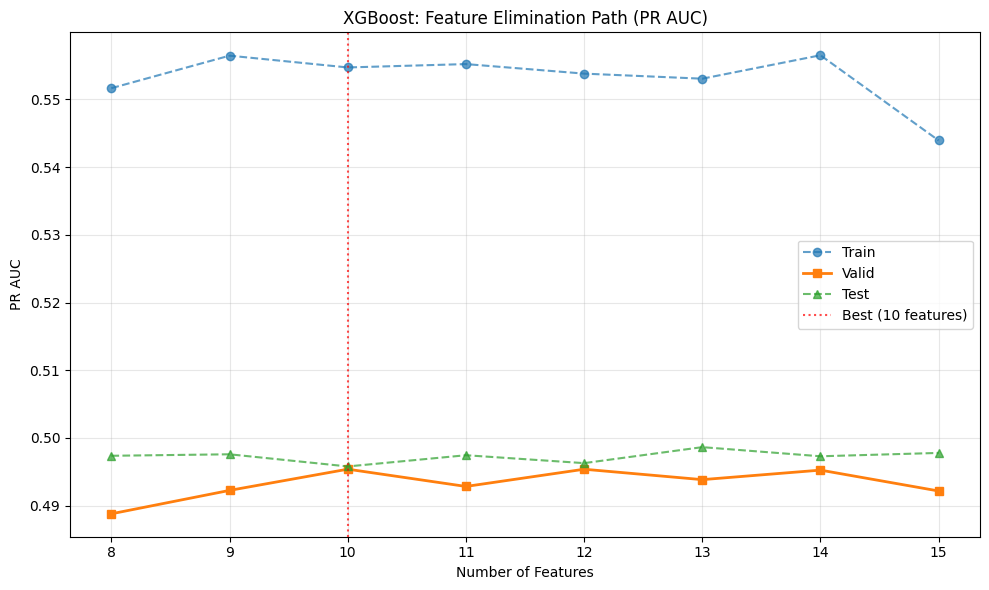

In [26]:
df_rfe = pd.DataFrame(list_results)[['int_n_features', 'flt_pr_auc_train', 'flt_pr_auc_valid', 'flt_pr_auc_test']]
df_rfe.sort_values('int_n_features', ascending=True, inplace=True)

# highlight the best
int_best_n = df_tuning['int_n_features'].iloc[0]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df_rfe['int_n_features'], df_rfe['flt_pr_auc_train'], 'o--', label='Train', alpha=0.7)
ax.plot(df_rfe['int_n_features'], df_rfe['flt_pr_auc_valid'], 's-', label='Valid', linewidth=2)
ax.plot(df_rfe['int_n_features'], df_rfe['flt_pr_auc_test'], '^--', label='Test', alpha=0.7)
ax.axvline(x=int_best_n, color='red', linestyle=':', alpha=0.7, label=f'Best ({int_best_n} features)')
ax.set_xlabel('Number of Features')
ax.set_ylabel('PR AUC')
ax.set_title('XGBoost: Feature Elimination Path (PR AUC)')
ax.set_xticks(df_rfe['int_n_features'].values)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{str_dirname_output}/rfe_path.png', bbox_inches='tight', dpi=150)
plt.show()

## Select Optimized Model

In [27]:
cls_model_inference = df_tuning['cls_model_inference'].iloc[0]

## Final Feature Count

In [28]:
list_feats_final = list(cls_model_inference.feature_names_in_)
int_n_features = len(list_feats_final)
print(f'N Features: {int_n_features}')

N Features: 10


## Final Model Metrics

In [29]:
for col in ['flt_roc_auc_train','flt_roc_auc_valid','flt_roc_auc_test','flt_pr_auc_train','flt_pr_auc_valid','flt_pr_auc_test']:
    flt_metric = df_tuning[col].iloc[0]
    print(f'{col}: {flt_metric:0.4f}')

flt_roc_auc_train: 0.8280
flt_roc_auc_valid: 0.8003
flt_roc_auc_test: 0.8008
flt_pr_auc_train: 0.5547
flt_pr_auc_valid: 0.4954
flt_pr_auc_test: 0.4958


## Save Tuning Results

In [30]:
str_filename = 'df_tuning.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
# save only the numeric metrics (exclude model objects and complex types)
list_save_cols = ['int_n_features', 'flt_roc_auc_train', 'flt_roc_auc_valid', 'flt_roc_auc_test',
                  'flt_pr_auc_train', 'flt_pr_auc_valid', 'flt_pr_auc_test']
df_tuning[list_save_cols].to_csv(str_local_path, index=False)

## SHAP Feature Importance (Final Model)

In [31]:
# sample
X_shap = X_valid[list_feats_final].sample(n=min(5000, len(X_valid[list_feats_final])), random_state=42)
# explainer
explainer = shap.TreeExplainer(cls_model_inference)
shap_values = explainer.shap_values(X_shap)
mean_abs_shap = np.abs(shap_values).mean(axis=0)
# make df
df_shap = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": mean_abs_shap,
})
df_shap.sort_values(by='mean_abs_shap', ascending=False, inplace=True)

# show
df_shap

,feature,mean_abs_shap
2,bureau_score,0.782550
9,ENG-loan_to_income,0.295250
4,delinq_12m,0.224001
5,utilization,0.208440
8,ENG-stated_income_log,0.202964
0,term_months,0.173406
6,inquiries_6m,0.170224
1,has_prior_loans_with_us,0.112635
3,open_trades,0.076764
7,public_records,0.015719


## SHAP Beeswarm Plot (Final Model)

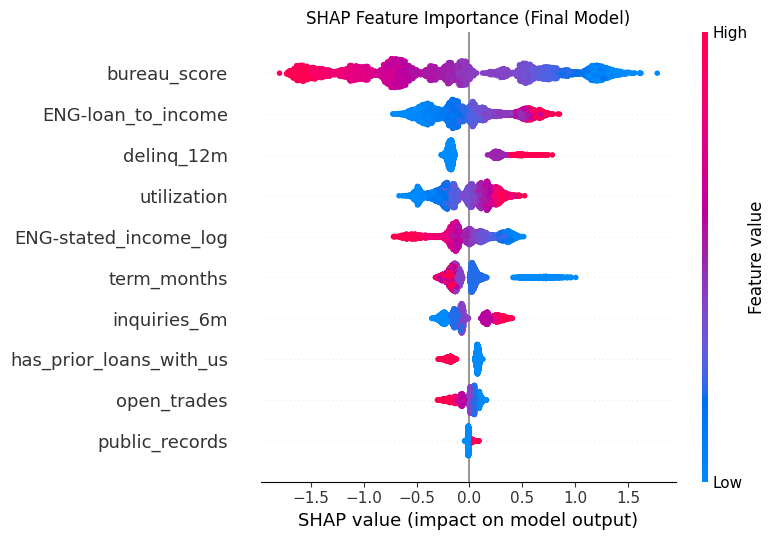

In [32]:
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_values, X_shap, show=False)
plt.title('SHAP Feature Importance (Final Model)')
plt.tight_layout()
plt.savefig(f'{str_dirname_output}/shap_final.png', bbox_inches='tight', dpi=150)
plt.show()

## Save Inference Model

In [33]:
# save
str_filename = 'cls_model_inference.joblib'
str_local_path = f'{str_dirname_output}/{str_filename}'
joblib.dump(cls_model_inference, str_local_path)

['./output/cls_model_inference.joblib']

## Isotonic Calibration

In [34]:
# Calibrate using isotonic regression -- only keep if it improves validation
y_hat_valid_uncal = cls_model_inference.predict_proba(X_valid[list_feats_final])[:, 1]
y_hat_test_uncal = cls_model_inference.predict_proba(X_test[list_feats_final])[:, 1]

iso_reg = IsotonicRegression(y_min=0, y_max=1, out_of_bounds='clip')
iso_reg.fit(y_hat_valid_uncal, y_valid)

# check if calibration improves validation PR AUC
y_hat_valid_cal = iso_reg.predict(y_hat_valid_uncal)
flt_valid_uncal = average_precision_score(y_valid, y_hat_valid_uncal)
flt_valid_cal = average_precision_score(y_valid, y_hat_valid_cal)

print(f'Validation PR AUC (Uncalibrated): {flt_valid_uncal:.4f}')
print(f'Validation PR AUC (Calibrated):   {flt_valid_cal:.4f}')

bool_use_calibration = flt_valid_cal > flt_valid_uncal

if bool_use_calibration:
    y_hat_test_cal = iso_reg.predict(y_hat_test_uncal)
    print(f'\nCalibration IMPROVES validation score. Using calibrated predictions.')
    print(f'Test PR AUC (Calibrated): {average_precision_score(y_test, y_hat_test_cal):.4f}')
    joblib.dump(iso_reg, f'{str_dirname_output}/cls_calibration.joblib')
else:
    y_hat_test_cal = None
    print(f'\nCalibration does NOT improve validation score. Skipping calibration.')

Validation PR AUC (Uncalibrated): 0.4954
Validation PR AUC (Calibrated):   0.4880

Calibration does NOT improve validation score. Skipping calibration.


## ROC, Precision-Recall, and Calibration Curves

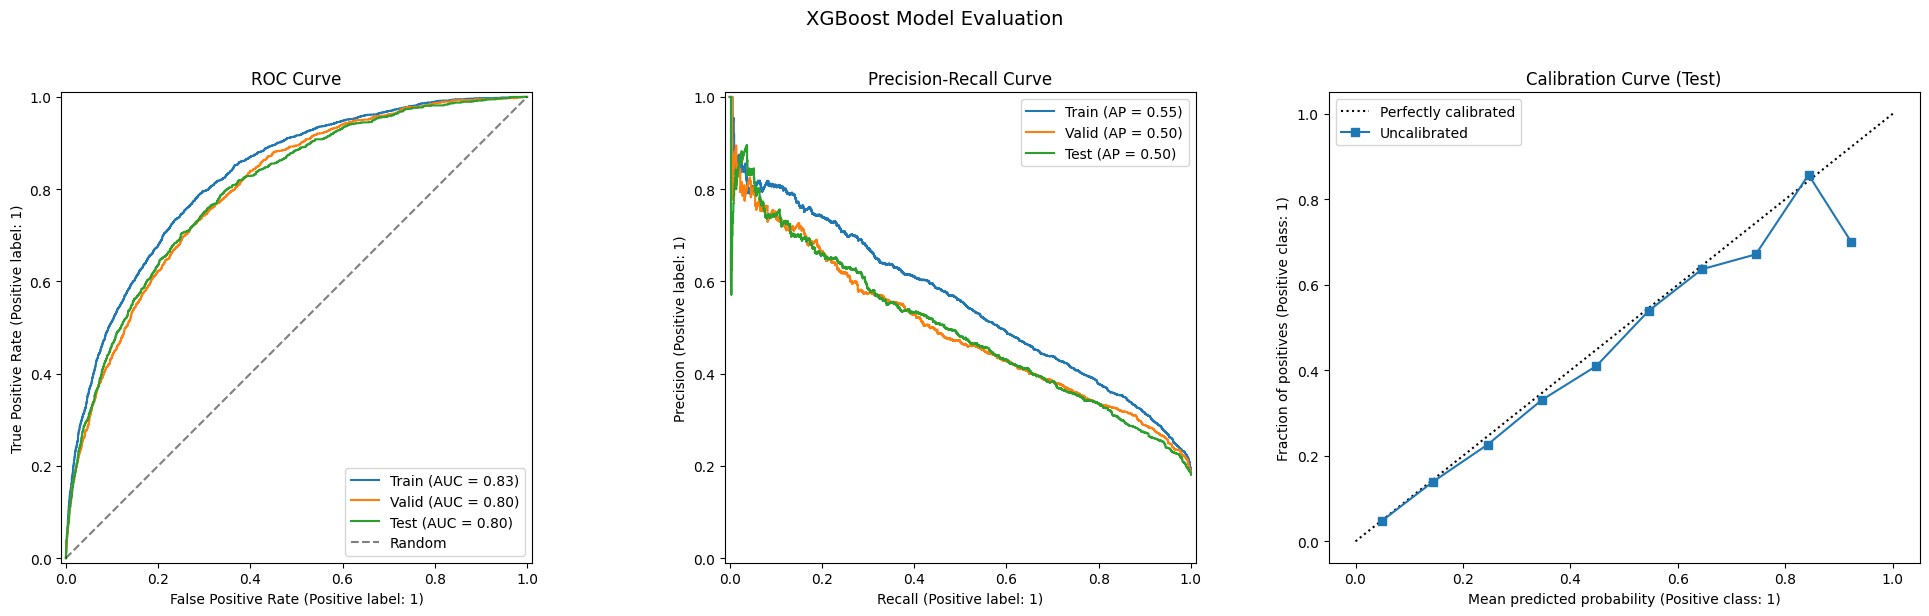

In [35]:
y_hat_train_final = cls_model_inference.predict_proba(X_train[list_feats_final])[:, 1]
y_hat_valid_final = cls_model_inference.predict_proba(X_valid[list_feats_final])[:, 1]
y_hat_test_final = cls_model_inference.predict_proba(X_test[list_feats_final])[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('XGBoost Model Evaluation', fontsize=14, y=1.02)

# ROC Curve
RocCurveDisplay.from_predictions(y_train, y_hat_train_final, name='Train', ax=axes[0])
RocCurveDisplay.from_predictions(y_valid, y_hat_valid_final, name='Valid', ax=axes[0])
RocCurveDisplay.from_predictions(y_test, y_hat_test_final, name='Test', ax=axes[0])
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
axes[0].set_title('ROC Curve')
axes[0].legend(loc='lower right')

# Precision-Recall Curve
PrecisionRecallDisplay.from_predictions(y_train, y_hat_train_final, name='Train', ax=axes[1])
PrecisionRecallDisplay.from_predictions(y_valid, y_hat_valid_final, name='Valid', ax=axes[1])
PrecisionRecallDisplay.from_predictions(y_test, y_hat_test_final, name='Test', ax=axes[1])
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(loc='upper right')

# Calibration Curve
CalibrationDisplay.from_predictions(y_test, y_hat_test_final, n_bins=10, name='Uncalibrated', ax=axes[2])
if y_hat_test_cal is not None:
    CalibrationDisplay.from_predictions(y_test, y_hat_test_cal, n_bins=10, name='Calibrated', ax=axes[2])
axes[2].set_title('Calibration Curve (Test)')
axes[2].legend(loc='upper left')

plt.tight_layout()
plt.savefig(f'{str_dirname_output}/roc_pr_calibration.png', bbox_inches='tight', dpi=150)
plt.show()

## Prediction Distribution Analysis

In [36]:
# import data
df = pd.read_csv(str_uri)
# dtm
df['dob'] = pd.to_datetime(df['dob'], errors='coerce')
# get age
df['age'] = (pd.Timestamp.today() - df['dob']).dt.days // 365
# make binary
df['age_group'] = df['age'].apply(
    lambda x: 'young' if x < 60 else 'old'
)
df

,loan_id,origination_date,dob,loan_amount,term_months,channel,employment_length_years,stated_income,state,has_prior_loans_with_us,...,utilization,inquiries_6m,public_records,default_12m,charged_off_amount,paid_interest_amount,apr,data_set,age,age_group
0,17794,2022-01-01,1992-02-29,5410,18,partner,8.39,2951.0,WI,0,...,0.47,3.0,1,0,0.00,1715.89,0.221,train,34,young
1,13499,2022-01-01,1966-05-05,10000,12,web,4.52,5410.0,FL,0,...,0.46,3.0,0,0,0.00,1672.59,0.209,train,59,young
2,24476,2022-01-01,1985-02-06,8480,12,web,3.81,3244.0,TX,0,...,0.48,5.0,2,0,0.00,2379.19,0.303,train,41,young
3,5438,2022-01-01,1981-11-06,3510,18,web,9.82,5147.0,IL,1,...,0.18,1.0,0,0,0.00,706.84,0.150,train,44,young
4,11493,2022-01-01,1991-11-27,6630,24,web,4.99,6389.0,TX,1,...,0.41,3.0,1,0,0.00,2160.10,0.159,train,34,young
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25303,23591,2024-12-28,1975-12-12,6970,12,mobile,9.41,6511.0,WA,0,...,0.47,4.0,1,0,0.00,1147.42,0.200,test,50,young
25304,15828,2024-12-28,1984-11-26,8450,12,mobile,8.97,4278.0,TN,1,...,0.52,2.0,0,0,0.00,1163.61,0.160,test,41,young
25305,17304,2024-12-28,2003-07-07,970,24,web,4.01,3885.0,MO,0,...,0.34,0.0,0,0,0.00,287.05,0.166,test,22,young
25306,13374,2024-12-28,1975-12-01,5700,12,mobile,7.10,13121.0,GA,0,...,0.31,2.0,2,0,0.00,803.60,0.156,test,50,young


In [37]:
# import preprocessor
str_filename = 'cls_model_preprocessing.joblib'
str_local_path = f'{str_dirname_output}/{str_filename}'
cls_model_preprocessing = joblib.load(str_local_path)

In [38]:
# preprocess df
df = cls_model_preprocessing.transform(X=df)

Generic cleaning...
Filling missing values...


100%|██████████| 12/12 [00:00<00:00, 1234.95it/s]

Feature engineering...


In [39]:
# import inference model
str_filename = 'cls_model_inference.joblib'
str_local_path = f'{str_dirname_output}/{str_filename}'
cls_model_inference = joblib.load(str_local_path)
# get cols
list_feats_final = list(cls_model_inference.feature_names_in_)

In [40]:
# generate predictions
df['yhat'] = cls_model_inference.predict_proba(df[list_feats_final])[:, 1]

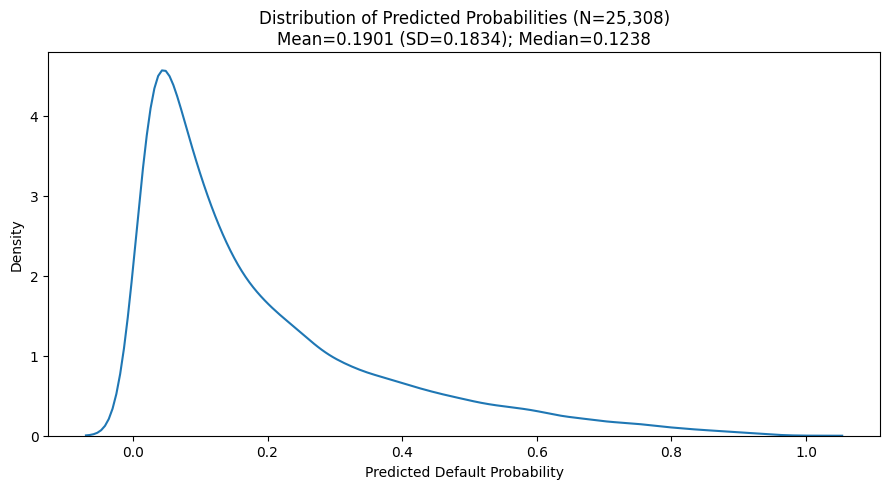

In [41]:
int_n = df.shape[0]
flt_mn = df['yhat'].mean()
flt_sd = df['yhat'].std()
flt_mdn = df['yhat'].median()

str_title = f'Distribution of Predicted Probabilities (N={int_n:,})\nMean={flt_mn:.4f} (SD={flt_sd:.4f}); Median={flt_mdn:.4f}'

fig, ax = plt.subplots(figsize=(9, 5))
ax.set_title(str_title)
sns.kdeplot(df['yhat'], ax=ax)
ax.set_xlabel('Predicted Default Probability')
plt.tight_layout()
plt.savefig(f'{str_dirname_output}/prediction_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

## Partial Dependence Plots

/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:721: FutureWarning: The column 1 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:721: FutureWarning: The column 7 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


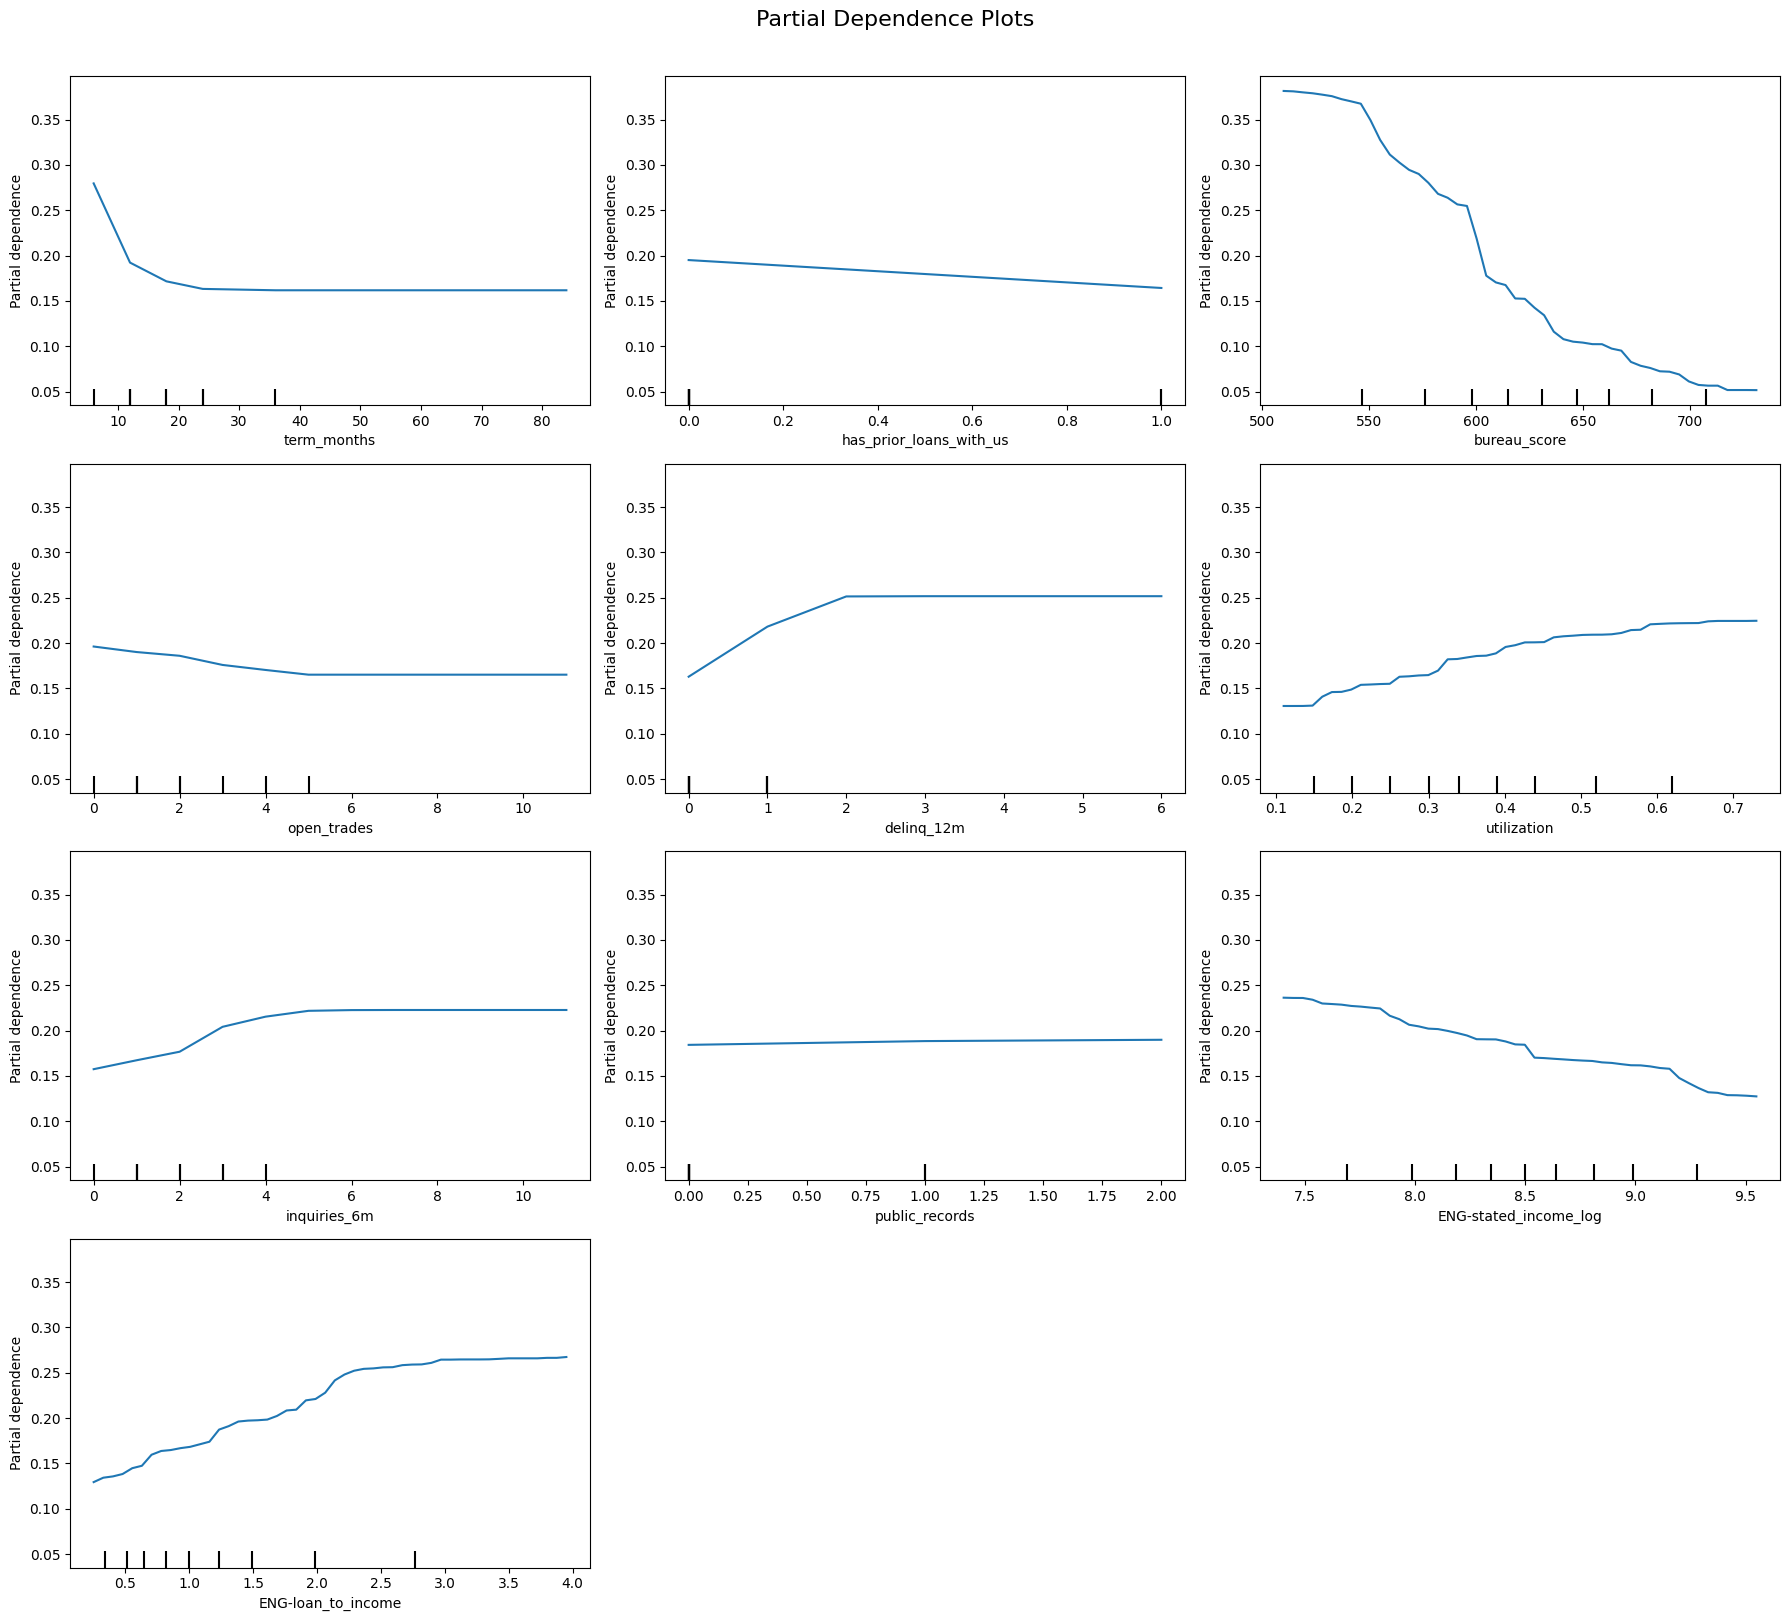

In [42]:
# use a sample for speed
X_pdp = df[list_feats_final].sample(n=min(2000, len(df)), random_state=42)

# number of features and grid layout
int_n_feats = len(list_feats_final)
int_n_cols = 3
int_n_rows = int(np.ceil(int_n_feats / int_n_cols))

fig, axes = plt.subplots(int_n_rows, int_n_cols, figsize=(6 * int_n_cols, 4 * int_n_rows))
axes = axes.flatten()

display = PartialDependenceDisplay.from_estimator(
    cls_model_inference,
    X_pdp,
    features=list(range(int_n_feats)),
    feature_names=list_feats_final,
    ax=axes[:int_n_feats],
    grid_resolution=50,
    kind='average',
)

# hide unused axes
for i in range(int_n_feats, len(axes)):
    axes[i].set_visible(False)

fig.suptitle('Partial Dependence Plots', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig(f'{str_dirname_output}/partial_dependence_plots.png', bbox_inches='tight', dpi=150)
plt.show()

## Disparate Impact Analysis (Age)

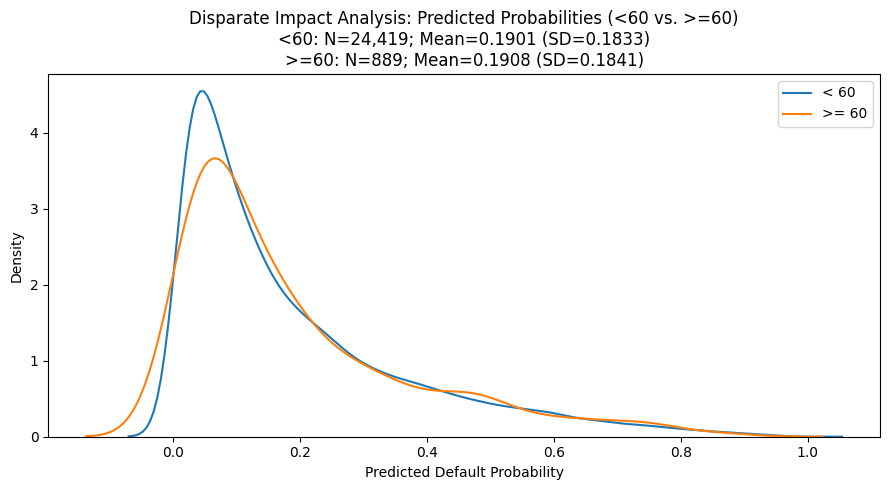

In [43]:
# plot - young
df_young = df[df['age_group'] == 'young'].copy()
int_n_young = df_young.shape[0]
flt_mn_young = df_young['yhat'].mean()
flt_sd_young = df_young['yhat'].std()
flt_mdn_young = df_young['yhat'].median()
# plot - old
df_old = df[df['age_group'] == 'old'].copy()
int_n_old = df_old.shape[0]
flt_mn_old = df_old['yhat'].mean()
flt_sd_old = df_old['yhat'].std()
flt_mdn_old = df_old['yhat'].median()

str_title = (f'Disparate Impact Analysis: Predicted Probabilities (<60 vs. >=60)\n'
             f'<60: N={int_n_young:,}; Mean={flt_mn_young:.4f} (SD={flt_sd_young:.4f})\n'
             f'>=60: N={int_n_old:,}; Mean={flt_mn_old:.4f} (SD={flt_sd_old:.4f})')

fig, ax = plt.subplots(figsize=(9, 5))
ax.set_title(str_title)
sns.kdeplot(df_young['yhat'], ax=ax, label='< 60')
sns.kdeplot(df_old['yhat'], ax=ax, label='>= 60')
ax.set_xlabel('Predicted Default Probability')
ax.legend()
plt.tight_layout()
plt.savefig(f'{str_dirname_output}/disparate_impact.png', bbox_inches='tight', dpi=150)
plt.show()

## Save Test Predictions (for Model Comparison)

In [44]:
dict_preds = {
    'y_test': y_test.values,
    'y_hat_test': y_hat_test_final,
}
if y_hat_test_cal is not None:
    dict_preds['y_hat_test_calibrated'] = y_hat_test_cal
else:
    dict_preds['y_hat_test_calibrated'] = y_hat_test_final  # use uncalibrated as fallback

df_test_preds = pd.DataFrame(dict_preds)
df_test_preds.to_csv(f'{str_dirname_output}/test_predictions.csv', index=False)
print(f'Saved {len(df_test_preds)} test predictions (calibrated={y_hat_test_cal is not None})')

Saved 6327 test predictions (calibrated=False)
